In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Hospital_Patient_Data.csv')

In [3]:
df.head(10)

,PatientID,Age,Gender,Hospital,Department,Doctor,Diagnosis,AdmissionType,AdmissionDate,DischargeDate,LengthOfStay_Days,BillingAmount,Status
0,PT1000,32.0,Male,Central Health Institute,Orthopedics,NaN,Diabetes,Emergency,2024-04-24,2024-04-25,1.0,1941.04,Discharged
1,PT1001,70.0,Male,St. Mary's Clinic,Neurology,Dr. Appiah,Fracture,Emergency,2024-07-22,2024-08-14,23.0,3472.25,Transferred
2,PT1002,46.0,Female,Central Health Institute,Emergency,Dr. Agyei,Diabetes,Outpatient,2024-04-14,2024-04-17,3.0,6810.46,Transferred
3,PT1003,85.0,Male,City General Hospital,Orthopedics,Dr. Darko,Fracture,Elective,2024-07-15,NaN,NaN,1977.61,Transferred
4,PT1004,69.0,Male,Northside Medical Centre,Emergency,Dr. Mensah,Migraine,Elective,2024-03-14,2024-04-03,20.0,5887.19,Admitted
5,PT1005,51.0,Male,St. Mary's Clinic,Neurology,Dr. Appiah,Anemia,Elective,2024-11-18,2024-11-25,7.0,7100.53,Deceased
6,PT1006,18.0,Male,St. Mary's Clinic,Neurology,Dr. Agyei,Anemia,Emergency,2025-01-05,2025-01-13,8.0,4174.31,Deceased
7,PT1007,2.0,Female,Northside Medical Centre,Emergency,Dr. Asante,Malaria,Emergency,2025-06-25,2025-07-04,9.0,5506.21,Transferred
8,PT1008,14.0,Male,St. Mary's Clinic,Pediatrics,Dr. Mensah,Anemia,Elective,2025-05-27,2025-06-21,25.0,6990.04,Discharged
9,PT1009,40.0,Male,City General Hospital,Neurology,Dr. Owusu,Typhoid,Emergency,2025-01-06,2025-02-04,29.0,2067.73,Deceased


In [4]:
df.shape

(515, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          515 non-null    object 
 1   Age                495 non-null    float64
 2   Gender             507 non-null    object 
 3   Hospital           515 non-null    object 
 4   Department         515 non-null    object 
 5   Doctor             495 non-null    object 
 6   Diagnosis          515 non-null    object 
 7   AdmissionType      515 non-null    object 
 8   AdmissionDate      515 non-null    object 
 9   DischargeDate      473 non-null    object 
 10  LengthOfStay_Days  473 non-null    float64
 11  BillingAmount      489 non-null    float64
 12  Status             515 non-null    object 
dtypes: float64(3), object(10)
memory usage: 52.4+ KB


In [6]:
df.describe()

,Age,LengthOfStay_Days,BillingAmount
count,495.000000,473.000000,489.000000
mean,44.040404,15.243129,4191.275971
std,24.790507,8.637845,2262.066019
min,1.000000,1.000000,201.530000
25%,22.000000,8.000000,2241.860000
50%,44.000000,15.000000,4136.140000
75%,65.500000,23.000000,6104.960000
max,85.000000,30.000000,7995.110000


In [7]:
df.nunique()

PatientID            500
Age                   85
Gender                 2
Hospital               5
Department             6
Doctor                 8
Diagnosis             10
AdmissionType          3
AdmissionDate        319
DischargeDate        325
LengthOfStay_Days     30
BillingAmount        475
Status                 4
dtype: int64

In [8]:
df.isnull().sum()

PatientID             0
Age                  20
Gender                8
Hospital              0
Department            0
Doctor               20
Diagnosis             0
AdmissionType         0
AdmissionDate         0
DischargeDate        42
LengthOfStay_Days    42
BillingAmount        26
Status                0
dtype: int64

In [9]:
df['Age'].fillna(df['Age'].median())
df['BillingAmount'] = df['BillingAmount'].fillna(df['BillingAmount'].median())

In [10]:
df.isnull().sum()

PatientID             0
Age                  20
Gender                8
Hospital              0
Department            0
Doctor               20
Diagnosis             0
AdmissionType         0
AdmissionDate         0
DischargeDate        42
LengthOfStay_Days    42
BillingAmount         0
Status                0
dtype: int64

In [11]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Doctor'] = df['Doctor'].fillna('Unknown')

In [12]:
df.isnull().sum()

PatientID             0
Age                  20
Gender                0
Hospital              0
Department            0
Doctor                0
Diagnosis             0
AdmissionType         0
AdmissionDate         0
DischargeDate        42
LengthOfStay_Days    42
BillingAmount         0
Status                0
dtype: int64

In [13]:
df['AdmissionDate'] = pd.to_datetime(df['AdmissionDate'])
df['DischargeDate'] = pd.to_datetime(df['DischargeDate'],errors='coerce')

In [14]:
df['Status'].value_counts()

Status
Discharged     141
Deceased       130
Admitted       129
Transferred    115
Name: count, dtype: int64

In [15]:
df[df['DischargeDate'].isnull()]['Status'].value_counts()

Status
Transferred    13
Admitted       11
Deceased       10
Discharged      8
Name: count, dtype: int64

In [16]:
# Calculated it from dates (only where DischargeDate exists)
df['Length_Calculated'] = (df['DischargeDate'] - df['AdmissionDate']).dt.days
# Compare with the given column 
df[['AdmissionDate','DischargeDate','LengthOfStay_Days','Length_Calculated']].head(10)

,AdmissionDate,DischargeDate,LengthOfStay_Days,Length_Calculated
0,2024-04-24,2024-04-25,1.0,1.0
1,2024-07-22,2024-08-14,23.0,23.0
2,2024-04-14,2024-04-17,3.0,3.0
3,2024-07-15,NaT,NaN,NaN
4,2024-03-14,2024-04-03,20.0,20.0
5,2024-11-18,2024-11-25,7.0,7.0
6,2025-01-05,2025-01-13,8.0,8.0
7,2025-06-25,2025-07-04,9.0,9.0
8,2025-05-27,2025-06-21,25.0,25.0
9,2025-01-06,2025-02-04,29.0,29.0


In [17]:
df.shape
df.duplicated().sum()

np.int64(15)

In [18]:
df = df.drop_duplicates()
df.shape

(500, 14)

In [19]:
df.shape

(500, 14)

In [20]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,18,35,55,75,100], labels=['Child','Young Adult','Adult','Senior','Elderly'])
df['AgeGroup'].value_counts()

AgeGroup
Adult          118
Senior         116
Child           98
Young Adult     85
Elderly         65
Name: count, dtype: int64

In [21]:
df[df['DischargeDate'].isnull()]['Status'].value_counts()

Status
Transferred    12
Admitted       11
Deceased       10
Discharged      7
Name: count, dtype: int64

In [22]:
df['AdmissionDate'] = pd.to_datetime(df['AdmissionDate'])
df['DischargeDate'] = pd.to_datetime(df['DischargeDate'], errors='coerce')

In [23]:
# Section 4 - Confirmation
print(df.dtypes)
print("\nshape after cleaning")
print(df.shape)
print("\nMissing values left(should be only DischargeDate and LengthOfStay):")
print(df.isnull().sum())

PatientID                    object
Age                         float64
Gender                       object
Hospital                     object
Department                   object
Doctor                       object
Diagnosis                    object
AdmissionType                object
AdmissionDate        datetime64[ns]
DischargeDate        datetime64[ns]
LengthOfStay_Days           float64
BillingAmount               float64
Status                       object
Length_Calculated           float64
AgeGroup                   category
dtype: object

shape after cleaning
(500, 15)

Missing values left(should be only DischargeDate and LengthOfStay):
PatientID             0
Age                  18
Gender                0
Hospital              0
Department            0
Doctor                0
Diagnosis             0
AdmissionType         0
AdmissionDate         0
DischargeDate        40
LengthOfStay_Days    40
BillingAmount         0
Status                0
Length_Calculated    40
AgeGroup 

## section 5 - Analysis

In [24]:
# Q1. How many patients are in each department?
df['Department'].value_counts()

Department
Cardiology          98
Emergency           93
Orthopedics         91
Neurology           81
General Medicine    69
Pediatrics          68
Name: count, dtype: int64

In [25]:
# Q2. What is the average BillingAmount per Hospital?
df.groupby('Hospital')['BillingAmount'].mean()

Hospital
Central Health Institute    4080.617451
City General Hospital       4295.015960
Lakewood Hospital           4148.223579
Northside Medical Centre    3930.432525
St. Mary's Clinic           4380.610857
Name: BillingAmount, dtype: float64

In [26]:
# Q3. What is the most common Diagnosis?
df['Diagnosis'].value_counts()

Diagnosis
Migraine        61
Malaria         61
Anemia          60
Diabetes        56
Pneumonia       52
Typhoid         50
Fracture        44
Asthma          44
Hypertension    38
Appendicitis    34
Name: count, dtype: int64

In [27]:
# Q4. What is the average LengthOfStay_Days by Department?
df.groupby('Department')['LengthOfStay_Days'].mean()

Department
Cardiology          16.451613
Emergency           14.388235
General Medicine    14.169231
Neurology           14.410959
Orthopedics         14.646341
Pediatrics          17.516129
Name: LengthOfStay_Days, dtype: float64

In [28]:
# Q5. How many patients were admitted under each AdmissionType?
df['AdmissionType'].value_counts()

AdmissionType
Elective      182
Outpatient    166
Emergency     152
Name: count, dtype: int64

In [29]:
# Q6. What percentage of patients are male vs female?
df['Gender'].value_counts(normalize=True) * 100

Gender
Male      50.4
Female    49.6
Name: proportion, dtype: float64

In [30]:
# Q7. Which Doctor has the highest number of patients?
df['Doctor'].value_counts().head(3)

Doctor
Dr. Agyei      73
Dr. Boateng    61
Dr. Mensah     60
Name: count, dtype: int64

In [31]:
# Q8. What is the total BillingAmount per Hospital?
df.groupby('Hospital')['BillingAmount'].sum()

Hospital
Central Health Institute    416222.98
City General Hospital       425206.58
Lakewood Hospital           394081.24
Northside Medical Centre    389112.82
St. Mary's Clinic           459964.14
Name: BillingAmount, dtype: float64

In [32]:
# Q9. filter only status = 'Deceased' - how many and what is their average age?
deceased = df[df['Status'] == 'Deceased']
print(f"Count Deceased: {len(deceased)}")
print(f"Average Age of Deceased: {deceased['Age'].mean():.1f} years")
print(f"Most common Diagnosis among Deceased:")
print(deceased['Diagnosis'].value_counts().head(3))

Count Deceased: 128
Average Age of Deceased: 38.5 years
Most common Diagnosis among Deceased:
Diagnosis
Typhoid    18
Malaria    18
Anemia     16
Name: count, dtype: int64


In [33]:
# Q10. Find the top 3 Diagnoses by average BillingAmount?
df.groupby('Diagnosis')['BillingAmount'].mean().sort_values(ascending=False).head(3)

Diagnosis
Fracture        4428.700000
Hypertension    4415.786842
Appendicitis    4341.512059
Name: BillingAmount, dtype: float64

## Section 6--Vitualisation (Final Step)

In [34]:
# setup
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look nice
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,4)

## Bar chart 1. Patient count by Age

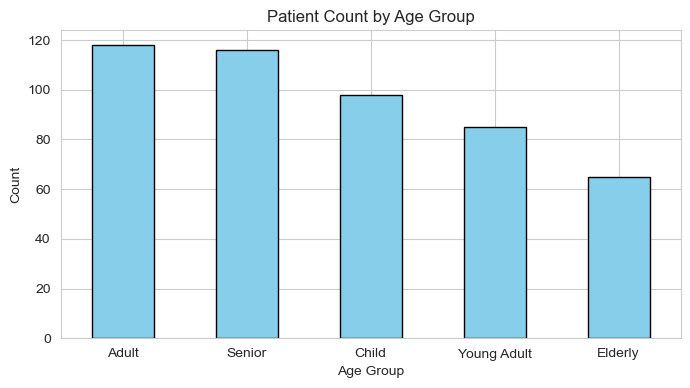

In [35]:
df['AgeGroup'].value_counts().plot(kind='bar' ,color='skyblue' ,edgecolor='black')
plt.title('Patient Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Chart 2- Histogram of Age Distribution

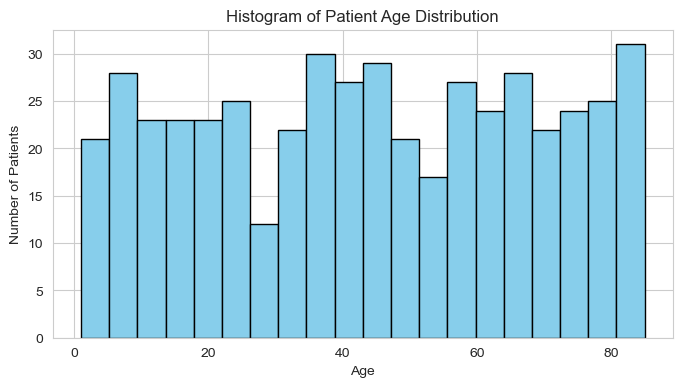

In [36]:
plt.hist(df['Age'], bins=20, color='skyblue',edgecolor='black')
plt.title('Histogram of Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()


## chart 3. Barchart of average billing by Department

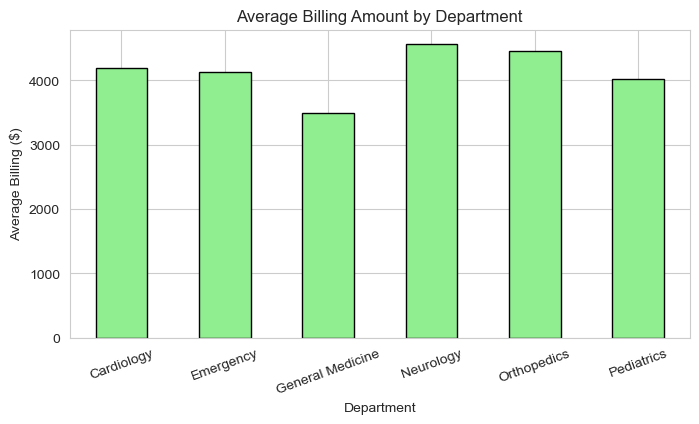

In [37]:
df.groupby('Department')['BillingAmount'].mean().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Average Billing Amount by Department')
plt.ylabel('Average Billing ($)')
plt.xticks(rotation=20)
plt.show()

## Chart 3. Patients Status Pie Chart.

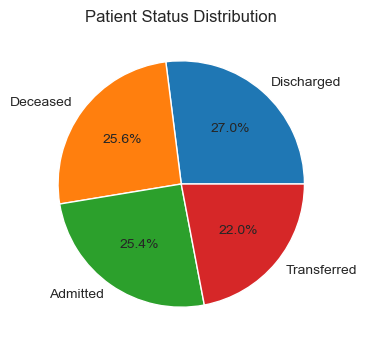

In [38]:
df['Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Patient Status Distribution')
plt.ylabel('')
plt.show()

## box plot of LengthOfStay by Department

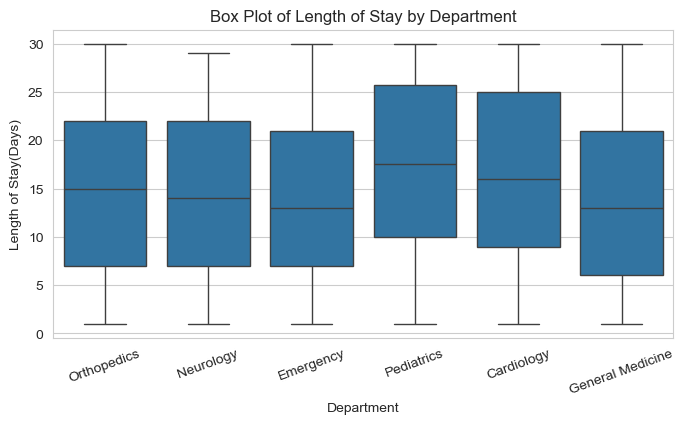

In [39]:
import seaborn as sns
sns.boxplot(data=df, x='Department', y='LengthOfStay_Days')
plt.title('Box Plot of Length of Stay by Department')
plt.xlabel('Department')
plt.ylabel('Length of Stay(Days)')
plt.xticks(rotation=20)
plt.show()

## conclunsion and key insights
* This project analysed 500 patients records( after removing 15 duplicatesfrom the hospital datasetusing python pandas, matplotlib and seaborn.
* tools used:** jupyter notebook
* challenges faces
**1. data cleaning issues
**2. coding errors in jupyter
**3. visualisation challenge
**4. learning curve: as abeginner , understanding difference between 'groupby(), value_counts() and also plotting syntax was difficult. i practicedeach chart multiple timesand used documentations.
* challenges helps us to gain more knowledge and grow